# TwiBot-22 Bot Detection
**Architecture**: LightGBM + XGBoost + Random Forest Ensemble with Threshold Tuning  
**Data**: Pre-processed tabular CSVs (train/val/test splits)

## Cell 1 — Install Dependencies

In [16]:
!pip install lightgbm xgboost scikit-learn pandas numpy matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Cell 2 — Imports & Seed

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)
print('All imports OK')

All imports OK


## Cell 3 — Mount Google Drive

In [18]:
# ---- UPDATE THIS PATH to where your CSVs are in Drive ----
DATA_DIR = './data/'

train_df = pd.read_csv(DATA_DIR + 'd2_train.csv')
val_df   = pd.read_csv(DATA_DIR + 'd2_val.csv')
test_df  = pd.read_csv(DATA_DIR + 'd2_test.csv')

print('Train shape :', train_df.shape)
print('Val shape   :', val_df.shape)
print('Test shape  :', test_df.shape)
print('\nColumns:')
print(train_df.columns.tolist())

Train shape : (35376, 12)
Val shape   : (10107, 12)
Test shape  : (5055, 12)

Columns:
['id', 'followers_count', 'following_count', 'tweet_count', 'listed_count', 'name_length', 'username_length', 'description_length', 'verified', 'protected', 'ff_ratio', 'label']


## Cell 4 — Quick Data Audit

In [19]:
# ---- UPDATE if your label column has a different name ----
LABEL_COL = 'label'

print('=== Train label distribution ===')
print(train_df[LABEL_COL].value_counts())
print(f'Bot ratio: {train_df[LABEL_COL].mean():.3f}')

print('\n=== Missing values (top 10) ===')
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

print('\n=== Sample rows ===')
train_df.head(3)

=== Train label distribution ===
label
1    29712
0     5664
Name: count, dtype: int64
Bot ratio: 0.840

=== Missing values (top 10) ===
id                    0
followers_count       0
following_count       0
tweet_count           0
listed_count          0
name_length           0
username_length       0
description_length    0
verified              0
protected             0
dtype: int64

=== Sample rows ===


,id,followers_count,following_count,tweet_count,listed_count,name_length,username_length,description_length,verified,protected,ff_ratio,label
0,u4107317134,481,870,67025,26,8,13,144,0,0,0.552874,0
1,u4858296837,202,712,158,5,17,12,104,0,0,0.283708,0
2,u232631847,278,342,4029,4,6,10,146,0,0,0.812865,0


## Cell 5 — Feature Engineering

In [20]:
def engineer_features(df):
    df = df.copy()
    eps = 1e-9

    # --- Account age ---
    if 'created_at' in df.columns:
        df['account_age_days'] = (
            pd.Timestamp.now() -
            pd.to_datetime(df['created_at'], errors='coerce', utc=True)
        ).dt.days.clip(lower=1)
    elif 'account_age_days' not in df.columns:
        df['account_age_days'] = 1  # fallback

    # Pull raw counts (handle alternate column names gracefully)
    fc  = df.get('followers_count',  pd.Series(np.zeros(len(df)))).fillna(0)
    frc = df.get('friends_count',    pd.Series(np.zeros(len(df)))).fillna(0)
    sc  = df.get('statuses_count',   pd.Series(np.zeros(len(df)))).fillna(0)
    lc  = df.get('listed_count',     pd.Series(np.zeros(len(df)))).fillna(0)
    fvc = df.get('favourites_count', pd.Series(np.zeros(len(df)))).fillna(0)
    age = df['account_age_days']

    # --- Core behavioral ratios ---
    df['ff_ratio']          = fc  / (frc + eps)
    df['tweet_freq']        = sc  / (age + eps)
    df['fav_freq']          = fvc / (age + eps)
    df['followers_per_day'] = fc  / (age + eps)
    df['listed_ratio']      = lc  / (fc  + eps)
    df['follow_back_rate']  = frc / (fc  + eps)
    df['fav_per_tweet']     = fvc / (sc  + eps)

    # --- Bot behavioral flags ---
    df['is_follow_heavy']    = (frc > 5000).astype(int)
    df['is_low_engagement']  = ((fc < 10) & (sc > 1000)).astype(int)
    df['is_high_freq_tweet'] = (df['tweet_freq'] > 50).astype(int)
    df['zero_followers']     = (fc == 0).astype(int)
    df['zero_following']     = (frc == 0).astype(int)
    df['zero_tweets']        = (sc == 0).astype(int)
    df['follower_gt_1k']     = (fc > 1000).astype(int)
    df['following_gt_1k']    = (frc > 1000).astype(int)

    # --- Profile completeness (bots often leave these blank) ---
    if 'description' in df.columns:
        df['has_description']  = df['description'].notna().astype(int)
        df['description_len']  = df['description'].fillna('').apply(len)
    if 'name' in df.columns:
        df['name_len']         = df['name'].fillna('').apply(len)
    if 'screen_name' in df.columns:
        sn = df['screen_name'].fillna('')
        df['screen_name_len']    = sn.apply(len)
        df['screen_name_digits'] = sn.apply(lambda x: sum(c.isdigit() for c in x))
        df['digit_ratio']        = df['screen_name_digits'] / (df['screen_name_len'] + eps)
    if 'verified' in df.columns:
        df['is_verified']        = df['verified'].fillna(False).astype(int)
    if 'default_profile' in df.columns:
        df['default_profile']    = df['default_profile'].fillna(True).astype(int)
    if 'default_profile_image' in df.columns:
        df['default_image']      = df['default_profile_image'].fillna(True).astype(int)
    if 'geo_enabled' in df.columns:
        df['geo_enabled']        = df['geo_enabled'].fillna(False).astype(int)

    # --- Log transforms for heavy-tailed distributions ---
    log_targets = ['followers_count', 'friends_count', 'statuses_count',
                   'listed_count', 'favourites_count', 'account_age_days',
                   'followers_per_day', 'tweet_freq', 'ff_ratio']
    for col in log_targets:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    return df


train_df = engineer_features(train_df)
val_df   = engineer_features(val_df)
test_df  = engineer_features(test_df)

print('Feature engineering done')
print('New shape:', train_df.shape)

Feature engineering done
New shape: (35376, 34)


## Cell 6 — Prepare Feature Matrix

In [21]:
# Columns to drop (non-numeric identifiers & label)
DROP_COLS = [
    LABEL_COL, 'id', 'user_id', 'created_at', 'name',
    'screen_name', 'description', 'url', 'location',
    'profile_image_url', 'profile_banner_url', 'entities'
]
DROP_COLS = [c for c in DROP_COLS if c in train_df.columns]

# Keep only numeric columns
NUMERIC_DTYPES = ['float64', 'int64', 'float32', 'int32', 'bool', 'uint8']
FEATURE_COLS = [
    c for c in train_df.columns
    if c not in DROP_COLS and train_df[c].dtype in NUMERIC_DTYPES
]

print(f'Total features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

X_train_raw = train_df[FEATURE_COLS].values
y_train     = train_df[LABEL_COL].values.astype(int)
X_val_raw   = val_df[FEATURE_COLS].values
y_val       = val_df[LABEL_COL].values.astype(int)
X_test_raw  = test_df[FEATURE_COLS].values
y_test      = test_df[LABEL_COL].values.astype(int)

# Impute missing + scale
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_val   = scaler.transform(imputer.transform(X_val_raw))
X_test  = scaler.transform(imputer.transform(X_test_raw))

num_bots   = (y_train == 1).sum()
num_humans = (y_train == 0).sum()
scale_w    = num_humans / num_bots
print(f'\nBots: {num_bots} | Humans: {num_humans} | scale_pos_weight: {scale_w:.2f}')

Total features: 32
['followers_count', 'following_count', 'tweet_count', 'listed_count', 'name_length', 'username_length', 'description_length', 'verified', 'protected', 'ff_ratio', 'account_age_days', 'tweet_freq', 'fav_freq', 'followers_per_day', 'listed_ratio', 'follow_back_rate', 'fav_per_tweet', 'is_follow_heavy', 'is_low_engagement', 'is_high_freq_tweet', 'zero_followers', 'zero_following', 'zero_tweets', 'follower_gt_1k', 'following_gt_1k', 'is_verified', 'log_followers_count', 'log_listed_count', 'log_account_age_days', 'log_followers_per_day', 'log_tweet_freq', 'log_ff_ratio']

Bots: 29712 | Humans: 5664 | scale_pos_weight: 0.19


## Cell 7 — Train LightGBM

In [22]:
lgb_model = lgb.LGBMClassifier(
    n_estimators      = 2000,
    learning_rate     = 0.03,
    num_leaves        = 63,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    scale_pos_weight  = scale_w,
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1
)

lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=200)
    ]
)

print(f'Best iteration: {lgb_model.best_iteration_}')

[200]	valid_0's binary_logloss: 0.110318
[400]	valid_0's binary_logloss: 0.104209
[600]	valid_0's binary_logloss: 0.102808
Best iteration: 644


## Cell 8 — Train XGBoost

In [23]:
xgb_model = XGBClassifier(
    n_estimators          = 2000,
    learning_rate         = 0.03,
    max_depth             = 6,
    min_child_weight      = 5,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_w,
    eval_metric           = 'logloss',
    early_stopping_rounds = 50,
    random_state          = SEED,
    n_jobs                = -1,
    verbosity             = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 200
)

print(f'Best iteration: {xgb_model.best_iteration}')

[0]	validation_0-logloss:0.67006


KeyboardInterrupt: 

## Cell 9 — Train Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators     = 500,
    max_depth        = None,
    min_samples_leaf = 5,
    class_weight     = 'balanced_subsample',
    random_state     = SEED,
    n_jobs           = -1
)

rf_model.fit(X_train, y_train)
print('Random Forest trained')

Random Forest trained


## Cell 10 — Ensemble + Threshold Tuning (Validation Set)

Optimal threshold : 0.2301
Val Precision     : 0.9748
Val Recall        : 0.9899
Val F1            : 0.9823


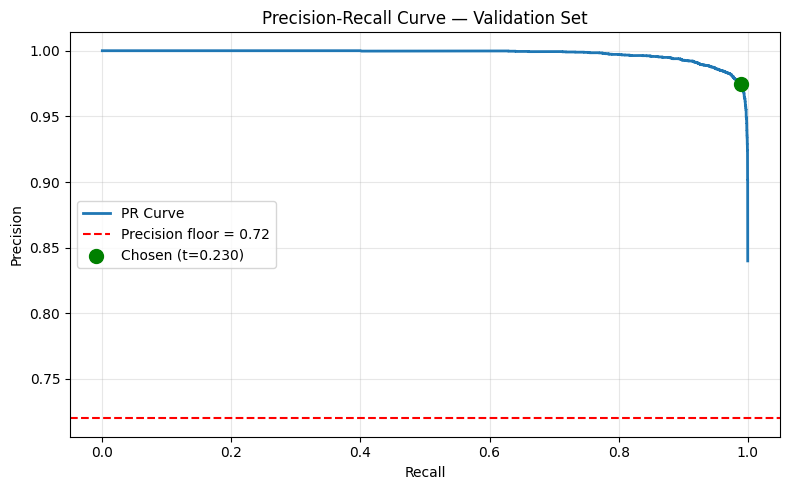

In [ ]:
# Soft vote ensemble on validation set
lgb_val = lgb_model.predict_proba(X_val)[:, 1]
xgb_val = xgb_model.predict_proba(X_val)[:, 1]
rf_val  = rf_model.predict_proba(X_val)[:, 1]

val_probs = 0.40 * lgb_val + 0.40 * xgb_val + 0.20 * rf_val

# --- Threshold tuning ---
PRECISION_FLOOR = 0.72   # lower this if recall is too low, raise to boost precision

precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, val_probs)

best_thresh = 0.5
best_f1     = 0.0

for p, r, t in zip(precision_arr[:-1], recall_arr[:-1], thresholds):
    if p >= PRECISION_FLOOR:
        f = 2 * p * r / (p + r + 1e-9)
        if f > best_f1:
            best_f1     = f
            best_thresh = t

val_preds = (val_probs >= best_thresh).astype(int)

print(f'Optimal threshold : {best_thresh:.4f}')
print(f'Val Precision     : {precision_score(y_val, val_preds):.4f}')
print(f'Val Recall        : {recall_score(y_val, val_preds):.4f}')
print(f'Val F1            : {f1_score(y_val, val_preds):.4f}')

# Plot PR curve
plt.figure(figsize=(8, 5))
plt.plot(recall_arr, precision_arr, lw=2, label='PR Curve')
plt.axhline(y=PRECISION_FLOOR, color='red', linestyle='--',
            label=f'Precision floor = {PRECISION_FLOOR}')
plt.scatter([recall_score(y_val, val_preds)],
            [precision_score(y_val, val_preds)],
            color='green', zorder=5, s=100, label=f'Chosen (t={best_thresh:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Validation Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()

## Cell 11 — Final Evaluation on Test Set
> ⚠️ Run this cell only once. Do not re-tune based on these results.

  Accuracy  : 0.9680
  Precision : 0.9731
  Recall    : 0.9892
  F1 Score  : 0.9811
  AUC-ROC   : 0.9914


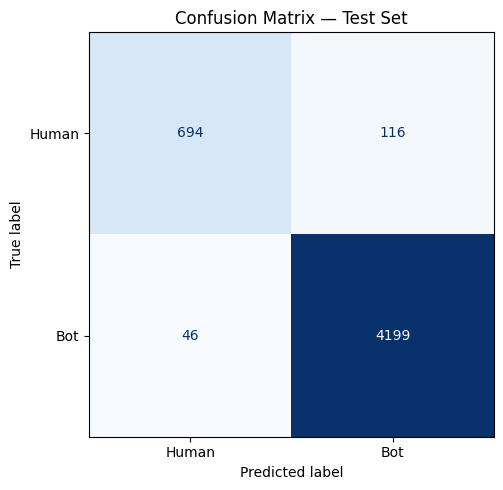

In [ ]:
# Ensemble on test set
lgb_test  = lgb_model.predict_proba(X_test)[:, 1]
xgb_test  = xgb_model.predict_proba(X_test)[:, 1]
rf_test   = rf_model.predict_proba(X_test)[:, 1]

test_probs = 0.40 * lgb_test + 0.40 * xgb_test + 0.20 * rf_test
test_preds = (test_probs >= best_thresh).astype(int)

print('=' * 45)
print(f'  Accuracy  : {accuracy_score(y_test, test_preds):.4f}')
print(f'  Precision : {precision_score(y_test, test_preds):.4f}')
print(f'  Recall    : {recall_score(y_test, test_preds):.4f}')
print(f'  F1 Score  : {f1_score(y_test, test_preds):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test, test_probs):.4f}')
print('=' * 45)

# Confusion matrix
cm   = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Human', 'Bot'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Cell 12 — Feature Importance

In [ ]:
# LightGBM feature importance (gain)
importance = lgb_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importance
}).sort_values('importance', ascending=False).head(25)

plt.figure(figsize=(9, 7))
sns.barplot(data=feat_imp_df, x='importance', y='feature', palette='viridis')
plt.title('Top 25 Features — LightGBM (Gain)')
plt.xlabel('Importance (Gain)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('\nTop 10 features:')
print(feat_imp_df[['feature', 'importance']].head(10).to_string(index=False))

## Cell 13 — Save Models to Drive (Optional)

In [ ]:
import pickle, os

SAVE_DIR = DATA_DIR + 'models/'
os.makedirs(SAVE_DIR, exist_ok=True)

lgb_model.booster_.save_model(SAVE_DIR + 'lgb_model.txt')
xgb_model.save_model(SAVE_DIR + 'xgb_model.json')

with open(SAVE_DIR + 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
with open(SAVE_DIR + 'preprocessor.pkl', 'wb') as f:
    pickle.dump({'imputer': imputer, 'scaler': scaler,
                 'feature_cols': FEATURE_COLS,
                 'threshold': best_thresh}, f)

print('All models saved to', SAVE_DIR)